<a href="https://colab.research.google.com/github/KoshKath/DataScience_Lab6_project/blob/main/Lab6_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy==1.26.4

In [2]:
!pip install kmodes==0.10.1

Dataset URL: https://www.kaggle.com/datasets/fahmidachowdhury/customer-segmentation-data-for-marketing-analysis
License(s): CC0-1.0
customer-segmentation-data-for-marketing-analysis.zip: Skipping, found more recently modified local copy (use --force to force download)
Файлы в директории:
['customer_segmentation_data.csv']
Данные успешно загружены. Состояние: (1000, 9)
   id  age  gender  income  spending_score  membership_years  \
0   1   38  Female   99342              90                 3   
1   2   21  Female   78852              60                 2   
2   3   60  Female  126573              30                 2   
3   4   40   Other   47099              74                 9   
4   5   65  Female  140621              21                 3   

   purchase_frequency preferred_category  last_purchase_amount  
0                  24          Groceries                113.53  
1                  42             Sports                 41.93  
2                  28           Clothing         

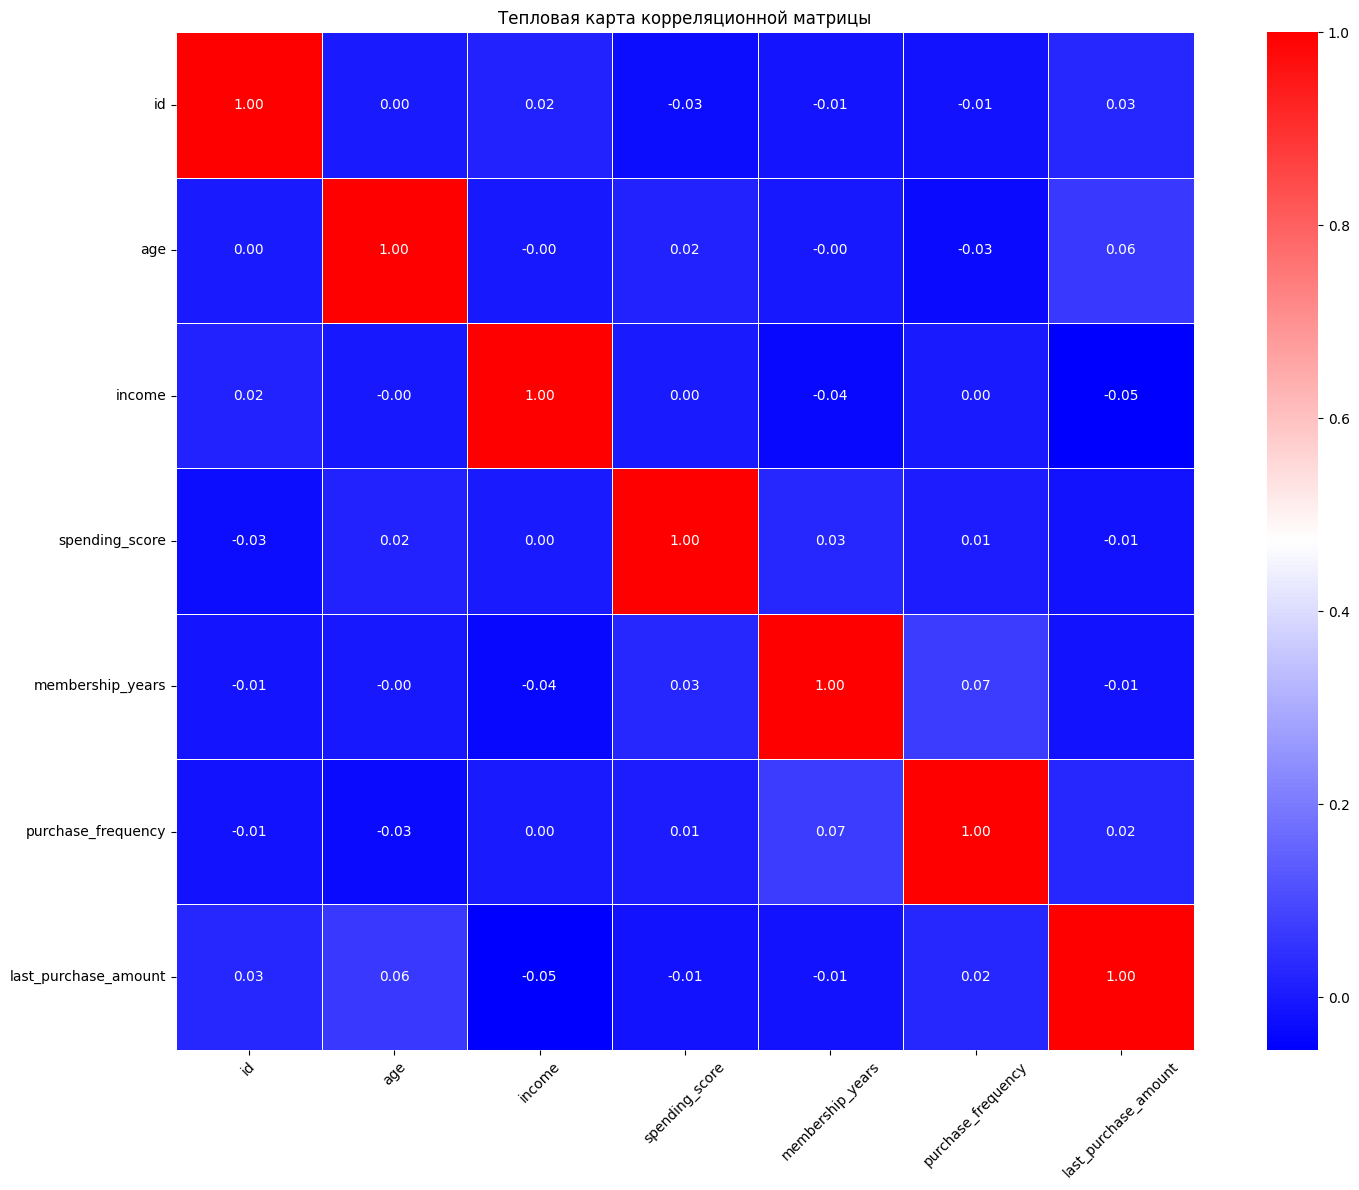

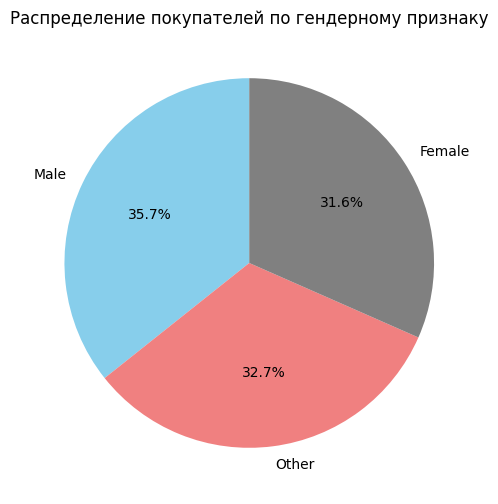

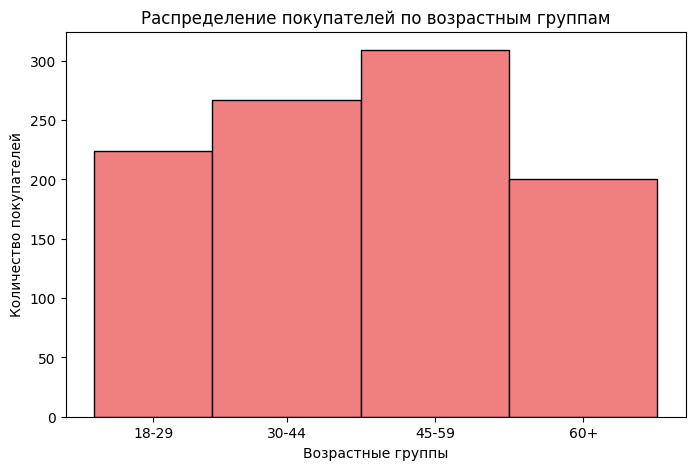

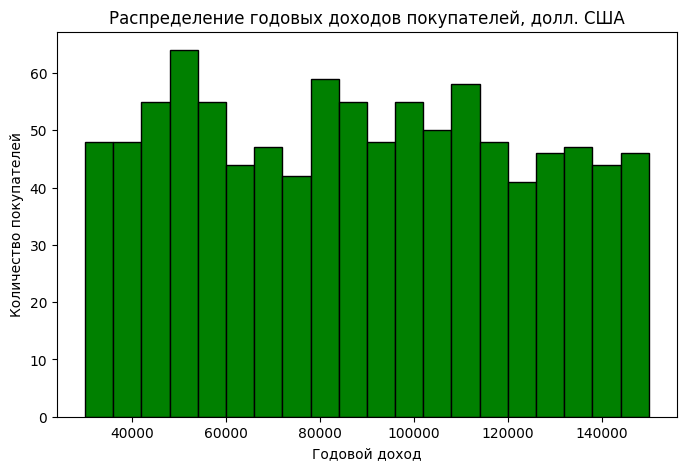

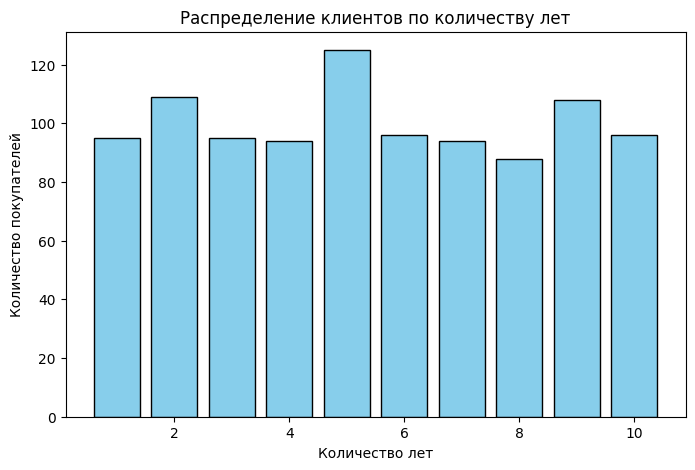

/content/data_quality.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['preferred_category'], palette='Set1')


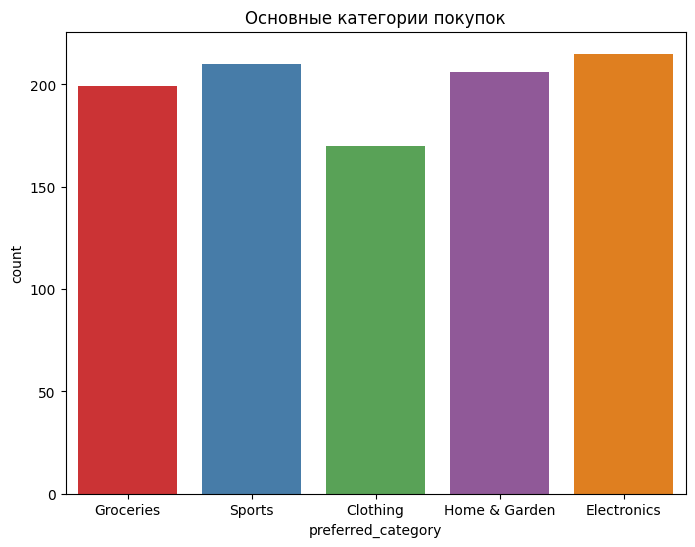


 Отчетная информация по выбросам:


,Количество выбросов
age,0
income,0
spending_score,0
membership_years,0
purchase_frequency,0
last_purchase_amount,0


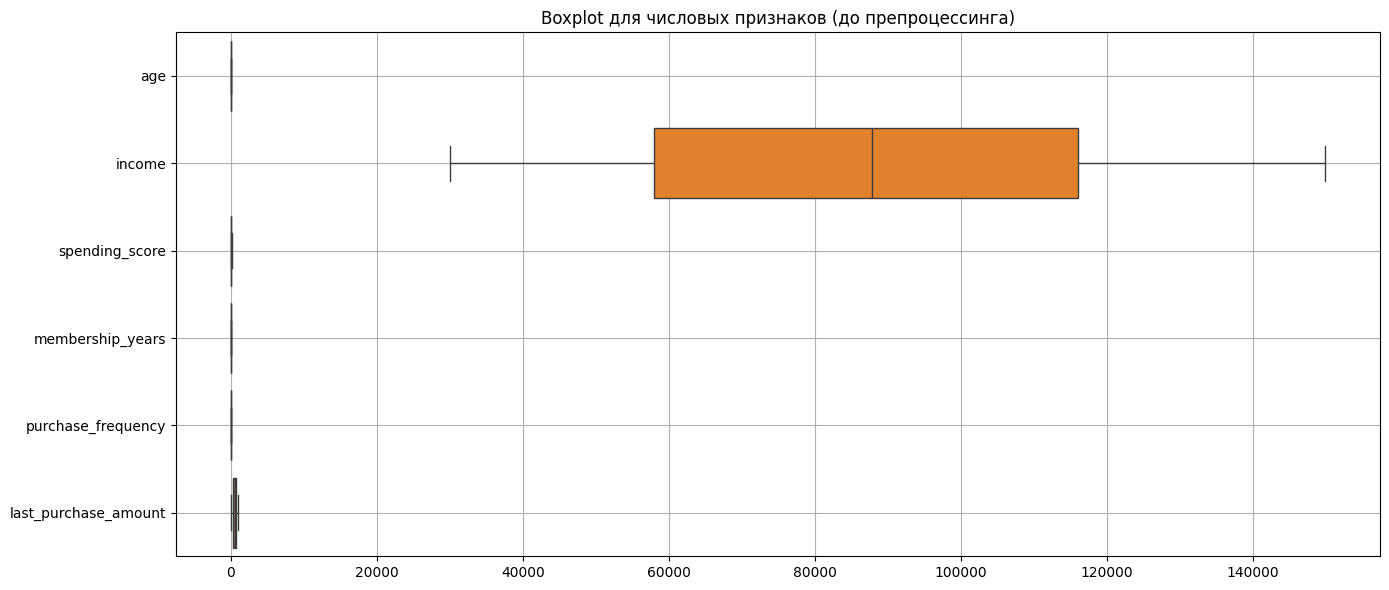

1. -- Результаты метода распространения близости --
Количество кластеров: 80


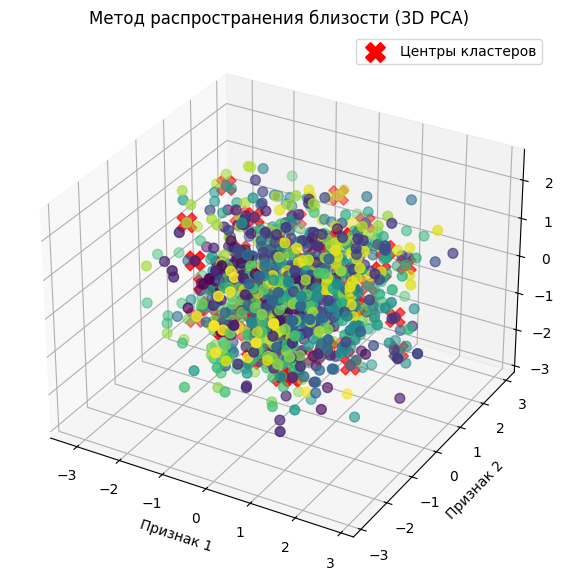

Метрики для AffinityPropagation:
  Силуэтовская оценка: 0.09
  Индекс Дэвиса-Болдуина: 1.76
  Индекс Калински-Харабаса: 21.93
-----------------////////-------------------
2. -- Результаты пространственной кластеризации на основе плотности --
Количество объектов в кластерах: 9
Количество объектов в шуме: 991
Процент шума: 99.10%


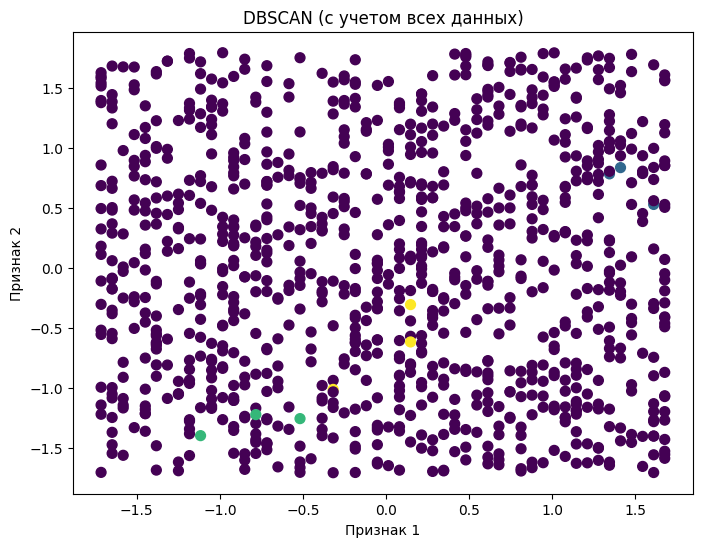

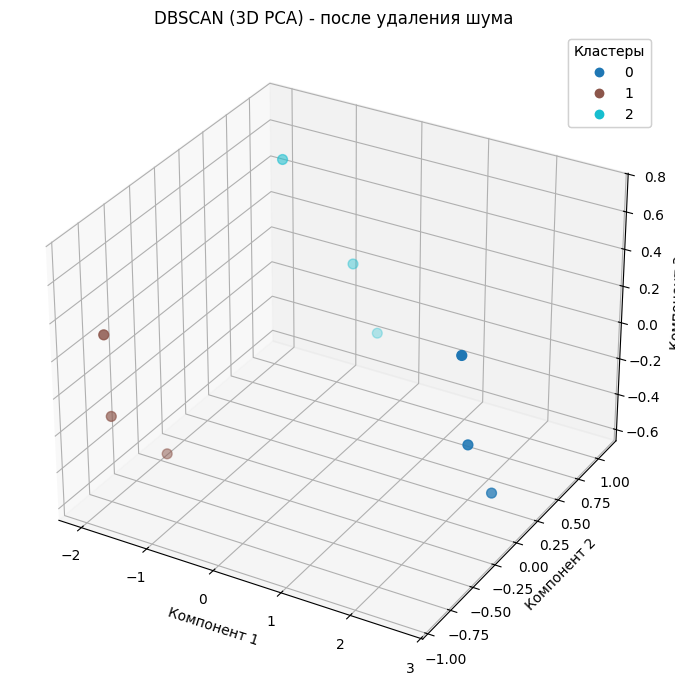

Метрики для DBSCAN:
  Силуэтовская оценка: 0.57
  Индекс Дэвиса-Болдуина: 0.52
  Индекс Калински-Харабаса: 34.14
-----------------////////-------------------
3. -- Результаты агломеративной кластеризации --


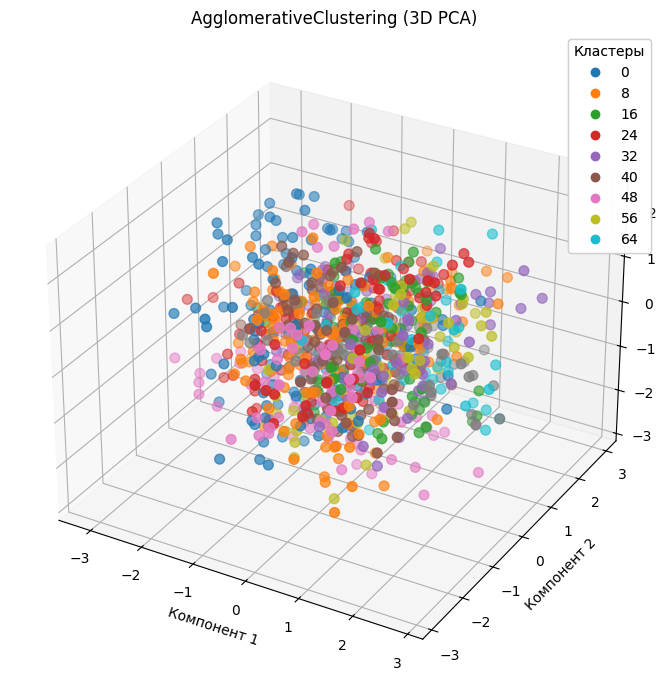

Метрики для AgglomerativeClustering:
  Силуэтовская оценка: 0.08
  Индекс Дэвиса-Болдуина: 1.77
  Индекс Калински-Харабаса: 23.72
-----------------////////-------------------
4. -- Результаты кластеризации на основе K-Modes --
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 318, cost: 783.0
Run 1, iteration: 2/100, moves: 0, cost: 783.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 932.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 783.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 76, cost: 786.0
Run 4, iteration: 2/100, moves: 0, cost: 786.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 281, cost: 793.0
Run 5, iteration: 2/100, moves: 0, cost

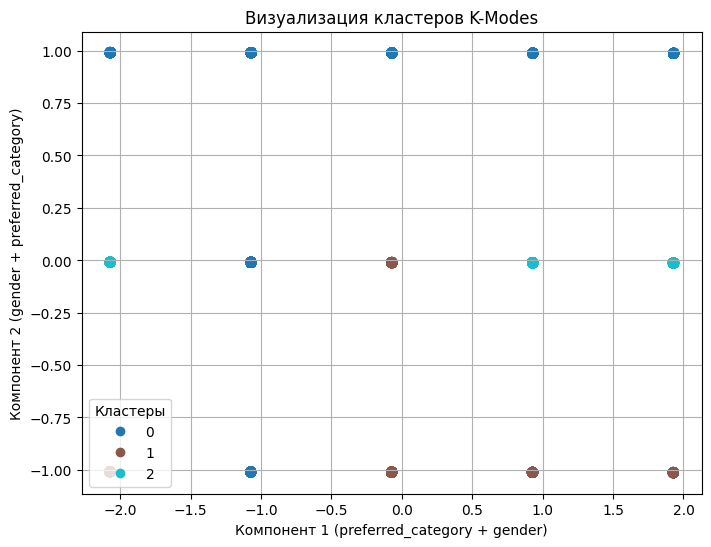

Метрики для KModes:
  Силуэтовская оценка: 0.16
  Индекс Дэвиса-Болдуина: 2.88
  Индекс Калински-Харабаса: 107.49
-----------------////////-------------------
5. -- Результаты кластеризации с помощью иерархий - HDBSCAN --
Количество кластеров (без учета шума): 2
Количество объектов в кластерах: 410
Количество объектов в шуме: 590
Процент шума: 59.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


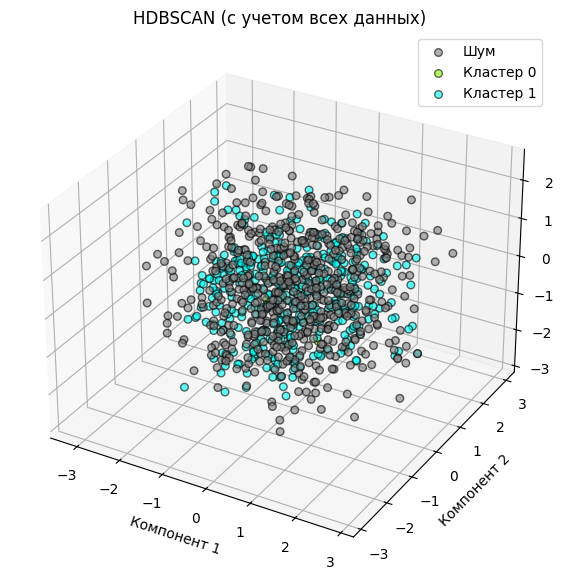

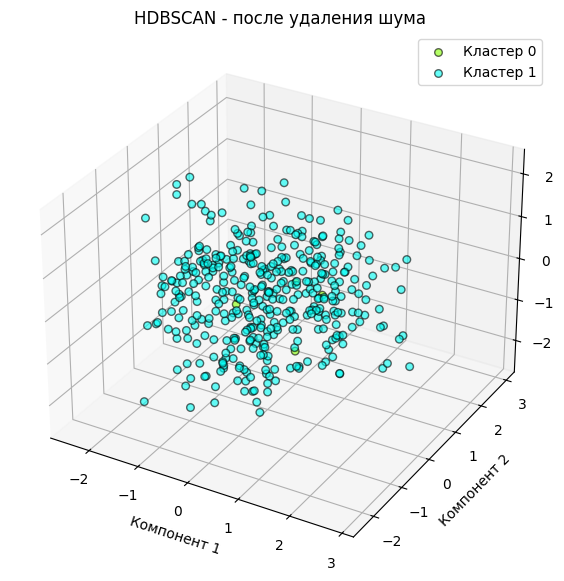

Метрики для HDBSCAN:
  Силуэтовская оценка: -0.06
  Индекс Дэвиса-Болдуина: 14.86
  Индекс Калински-Харабаса: 2.68
-----------------////////-------------------

 Итоговые метрики по примененным к датасету алгоритмам:
                         silhouette  davies_bouldin  calinski_harabasz
AffinityPropagation        0.089691        1.756084          21.930116
DBSCAN                     0.573030        0.520069          34.144043
AgglomerativeClustering    0.079241        1.769487          23.722753
KModes                     0.156072        2.880823         107.486339
HDBSCAN                   -0.062254       14.859238           2.681977


In [3]:
# main.py
!pip install kaggle
import os
import shutil
import zipfile
import pandas as pd
import ml_module as ml
import data_quality as dq
import calc_metrics as cmt
import AffinityPropagation as aff
import AgglomerativeClustering as agg
import DBSCAN as dbs
import HDBSCAN as hdbs
import KModes as km

# загрузка датасета из источника
#https://www.kaggle.com/datasets/fahmidachowdhury/customer-segmentation-data-for-marketing-analysis

# определение пути источника и назначения
source_path = 'kaggle.json'
destination_dir = os.path.expanduser('~/.kaggle')
destination_path = os.path.join(destination_dir, 'kaggle.json')
# создание директории назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)
# перемещение файла
shutil.move(source_path, destination_path)
# устанавление прав доступа
os.chmod(destination_path, 0o600)

!kaggle datasets download -d fahmidachowdhury/customer-segmentation-data-for-marketing-analysis

# распаковка скачанного архива
with zipfile.ZipFile('customer-segmentation-data-for-marketing-analysis.zip', 'r') as zip_ref:
  zip_ref.extractall('customer-segmentation-data-for-marketing-analysis')
# просмотр файлов в директории
print('Файлы в директории:')
print(os.listdir('customer-segmentation-data-for-marketing-analysis'))

ds_path = 'customer-segmentation-data-for-marketing-analysis/customer_segmentation_data.csv'
df = ml.data_load(ds_path)
dq.data_quality(df)
X, preprocessor = ml.preprocess_data(df)

all_metrics = {}

# Кластеризация по методу распространения близости
print('1. -- Результаты метода распространения близости --')
labels_af = aff.affinitypropagation(X)
metrics_af = cmt.calc_metrics(X, labels_af, 'AffinityPropagation')
if metrics_af:
    all_metrics.update(metrics_af)
print('-----------------////////-------------------')

# Пространственная кластеризация на основе плотности
print('2. -- Результаты пространственной кластеризации на основе плотности --')
X_core, labels_core = dbs.mdbscan(X)
if X_core is not None and labels_core is not None:
    metrics_db = cmt.calc_metrics(X_core, labels_core, 'DBSCAN')
    if metrics_db:
        all_metrics.update(metrics_db)
else:
    print("Нет данных для расчёта метрик")
print('-----------------////////-------------------')

# Агломеративная кластеризация
print('3. -- Результаты агломеративной кластеризации --')
X_ag, labels_ag = agg.agglomerativecluster(X)
if X_ag is not None and labels_ag is not None:
    metrics_ag = cmt.calc_metrics(X_ag, labels_ag, 'AgglomerativeClustering')
    if metrics_ag:
        all_metrics.update(metrics_ag)
print('-----------------////////-------------------')

# Кластеризация на основе K-Modes
print('4. -- Результаты кластеризации на основе K-Modes --')
X_cat, labels_kmodes = km.kmodes(df)
if X_cat is not None and labels_kmodes is not None:
    metrics_km = cmt.calc_metrics(X_cat, labels_kmodes, 'KModes')
    if metrics_km:
        all_metrics.update(metrics_km)
else:
    print("Нет данных для расчёта метрик")
print('-----------------////////-------------------')

# Кластеризация с помощью иерархий HDBSCAN
print('5. -- Результаты кластеризации с помощью иерархий - HDBSCAN --')
labels_hdb = hdbs.hdbscn(X)
metrics_hdb = cmt.calc_metrics(X, labels_hdb, 'HDBSCAN')
if metrics_hdb:
    all_metrics.update(metrics_hdb)
print('-----------------////////-------------------')

print('\n Итоговые метрики по примененным к датасету алгоритмам:')
print(pd.DataFrame(all_metrics).T)

In [ ]:
# ml_module.py
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
#from scipy import sparse

def data_load(ds_path):
  # загрузка данных файла CSV в DataFrame
  df = pd.read_csv(ds_path)
  print('Данные успешно загружены. Состояние:', df.shape)
  # просмотр 5-ти первых строк датасета
  print(df.head())
  # получение общей инфы о датасете
  print(df.info())
  # вывод статистических данных о числовых столбцах
  print(df.describe())
  return df

def preprocess_data(df):
  if df is None:
        print("Датасет не найден. Проверьте загрузку файла.")
        return None, None, None

  # исключение из признаков ID
  X = df.drop(columns=['id'])

  # определение признаков (числ. и категории):
  # категории
  categorical_features = X.select_dtypes(include=['object']).columns # 'gender', 'preferred_category'
  # числовые
  numeric_features = X.select_dtypes(include=['int64','float64']).columns # остальные

  # создание препроцессора
  numeric_transformer = StandardScaler()
  categorical_transformer = OneHotEncoder()
  preprocessor = ColumnTransformer(
      transformers=[
          ('num', numeric_transformer, numeric_features),
          ('cat', categorical_transformer, categorical_features)
  ])

  # применение препроцессора к данным
  X_processed_array = preprocessor.fit_transform(X)
  # получение колонок после OneHotEncoder
  if categorical_features.size > 0:
     transformed_categoric_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
  else:
     transformed_categoric_cols = []

  # восстановление колонок (числ. и категории)
  all_cols = list(numeric_features) + list(transformed_categoric_cols)

  # восстановление DataFrame с правильными колонками после ColumnTransformer
  X_processed = pd.DataFrame(X_processed_array, columns=all_cols, index=X.index)
  return X_processed, preprocessor

In [ ]:
# data_quality.py
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

def data_quality(df):
  print('\nKоличество пропусков в каждом столбце:')
  print(df.isnull().sum())

  print('\nKорреляционная матрица:')
  corr_matrix = df.corr(numeric_only=True)
  plt.figure(figsize=(16, 12))
  sns.heatmap(corr_matrix, annot=True, cmap='bwr', fmt=".2f", square=True, linewidths=.5)
  plt.title('Тепловая карта корреляционной матрицы')
  plt.xticks(rotation=45)
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()

  # круговая диаграмма (покупатели по гендерному признаку)
  gender_counts = df['gender'].value_counts()
  plt.figure(figsize=(6,6))
  plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'gray'])
  plt.title('Распределение покупателей по гендерному признаку')
  plt.show()

  # гистограмма распределения покупателей по возрастным группам
  bins = [18, 30, 45, 60, 75]
  labels = ['18-29', '30-44', '45-59', '60+']
  plt.figure(figsize=(8,5))
  counts, _, _ = plt.hist(x=df['age'], bins=bins, edgecolor='black', color='lightcoral')
  bin_centers = [(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)]
  plt.xticks(bin_centers, labels)
  plt.xlabel('Возрастные группы')
  plt.ylabel('Количество покупателей')
  plt.title('Распределение покупателей по возрастным группам')
  plt.show()

  # гистограмма распределения доходов покупателей
  plt.figure(figsize=(8,5))
  plt.hist(x=df['income'], bins=20, color='green', edgecolor='black')
  plt.xlabel('Годовой доход')
  plt.ylabel('Количество покупателей')
  plt.title('Распределение годовых доходов покупателей, долл. США')
  plt.show()

  # гистограмма количества лет, в течение которых покупатель является клиентом сети
  years = df['membership_years']
  counts = years.value_counts().sort_index()
  plt.figure(figsize=(8,5))
  plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
  plt.xlabel('Количество лет')
  plt.ylabel('Количество покупателей')
  plt.title('Распределение клиентов по количеству лет')
  plt.show()

  # гистограмма покупок
  plt.figure(figsize=(8, 6))
  sns.countplot(x=df['preferred_category'], palette='Set1')
  plt.title('Основные категории покупок')
  plt.show()

  # исследование выбросов - озучение числовых колонок df
  numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
  if 'id' in numeric_cols:
      numeric_cols = numeric_cols.drop('id')

  if len(numeric_cols) == 0:
      print("Нет числовых признаков для анализа.")
      return

  # подсчёт выбросов по IQR
  outlier_counts = {}
  for col in numeric_cols:
      q1 = df[col].quantile(0.25)
      q3 = df[col].quantile(0.75)
      iqr = q3 - q1
      lower_bound = q1 - 1.5 * iqr
      upper_bound = q3 + 1.5 * iqr
      outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
      outlier_counts[col] = len(outliers)

  # вывод отчета по выбросам
  print("\n Отчетная информация по выбросам:")
  outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
  display(outlier_series.to_frame(name="Количество выбросов"))

  # визуализация ящиков с усами
  num_features = len(numeric_cols)
  height = max(6, num_features * 0.5)

  plt.figure(figsize=(14, height))
  sns.boxplot(data=df[numeric_cols], orient='h')
  plt.title("Boxplot для числовых признаков (до препроцессинга)")
  plt.tight_layout()
  plt.grid(True)
  plt.show()
  return

In [ ]:
# calc_metrics.py
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def calc_metrics(X, labels, method_name):
    metrics = {}
    if len(set(labels)) < 2:
        print(f"Метрики для {method_name} не рассчитаны — меньше 2 кластеров.")
        return None

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    metrics[method_name] = {
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    }

    print(f"Метрики для {method_name}:")
    print(f"  Силуэтовская оценка: {sil:.2f}")
    print(f"  Индекс Дэвиса-Болдуина: {db:.2f}")
    print(f"  Индекс Калински-Харабаса: {ch:.2f}")
    return metrics

In [ ]:
# AffinityPropagation.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

def affinitypropagation(X):
  # создание модели Affinity Propagation
  AF = AffinityPropagation(random_state=0)

  # обучение модели
  AF.fit(X)

  # получение кластеров и их центров
  cluster_centers_indices = AF.cluster_centers_indices_
  labels = AF.labels_

  # вывод результатов
  n_clusters_ = len(cluster_centers_indices)
  print(f"Количество кластеров: {n_clusters_}")

  # визуализация
  n_features = X.shape[1]
  n_components = min(3, n_features)
  pca = PCA(n_components=n_components)
  X_pca = pca.fit_transform(X)

  if n_components == 3:
      fig = plt.figure(figsize=(10, 7))
      ax = fig.add_subplot(111, projection='3d')
      scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap='viridis', s=50)
      centers_pca = X_pca[cluster_centers_indices]
      ax.scatter(centers_pca[:, 0], centers_pca[:, 1], centers_pca[:, 2], c='red', marker='X', s=200, label='Центры кластеров')
      ax.set_title('Метод распространения близости (3D PCA)')
      ax.set_xlabel('Признак 1')
      ax.set_ylabel('Признак 2')
      ax.set_zlabel('Признак 3')
      ax.legend()
  else:
      plt.figure(figsize=(8, 6))
      plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', marker='o', s=50)
      plt.scatter(X_pca[cluster_centers_indices, 0], X_pca[cluster_centers_indices, 1], c='red', marker='X', s=200, label='Центры кластеров')
      plt.title('Метод распространения близости (2D PCA)')
      plt.xlabel('Признак 1')
      plt.ylabel('Признак 2')
      plt.legend()
  plt.show()
  return labels

In [ ]:
# AgglomerativeClustering.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D

def agglomerativecluster(X):
  # применение агломеративной кластеризации
  n_clusters = 70  # количество кластеров
  AgCLSTR = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
  predicted_labels = AgCLSTR.fit_predict(X)

  # визуализация после PCA (3D)
  pca = PCA(n_components=3)
  X_pca = pca.fit_transform(X)

  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')
  scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=predicted_labels, cmap='tab10', s=50)
  ax.set_title("AgglomerativeClustering (3D PCA)")
  ax.set_xlabel("Компонент 1")
  ax.set_ylabel("Компонент 2")
  ax.set_zlabel("Компонент 3")
  legend1 = ax.legend(*scatter.legend_elements(), title="Кластеры")
  ax.add_artist(legend1)
  plt.tight_layout()
  plt.show()
  return X, predicted_labels

In [ ]:
# DBSCAN.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

def mdbscan(X):
  # применение DBSCAN (Пространственная кластеризация на основе плотности)
  dbscan = DBSCAN(eps=1.0, min_samples=3)
  predicted_labels = dbscan.fit_predict(X)

  # анализ шума в данных
  df_clusters = pd.DataFrame(X.copy())
  df_clusters['cluster'] = predicted_labels

  noise_points = df_clusters[df_clusters['cluster'] == -1]
  clustered_points = df_clusters[df_clusters['cluster'] != -1]

  print(f"Количество объектов в кластерах: {len(clustered_points)}")
  print(f"Количество объектов в шуме: {len(noise_points)}")
  print(f"Процент шума: {len(noise_points) / len(df_clusters) * 100:.2f}%")

  # визуализация кластеров
  plt.figure(figsize=(8, 6))
  plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=predicted_labels, cmap='viridis', s=50)
  plt.title("DBSCAN (с учетом всех данных)")
  plt.xlabel("Признак 1")
  plt.ylabel("Признак 2")
  plt.show()

  # вычисление метрик качества (игнорирование метки -1 для шума)
  mask = predicted_labels != -1  # маска для отброса шума
  if sum(mask) == 0:
      print("После удаления шума не осталось точек.")
      return

  labels_core = predicted_labels[mask]
  X_core = X.loc[mask]

  if len(set(labels_core)) < 2:
      print("Недостаточно кластеров для вычисления метрик (нужно минимум 2).")
      return X_core, labels_core  # Возвращаем, чтобы можно было понять, что мало кластеров

  # визуализация после PCA (3D) удаления после шума
  pca = PCA(n_components=3)
  X_pca = pca.fit_transform(X_core)

  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')
  scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_core, cmap='tab10', s=50)
  ax.set_title("DBSCAN (3D PCA) - после удаления шума")
  ax.set_xlabel("Компонент 1")
  ax.set_ylabel("Компонент 2")
  ax.set_zlabel("Компонент 3")
  legend1 = ax.legend(*scatter.legend_elements(), title="Кластеры")
  ax.add_artist(legend1)
  plt.tight_layout()
  plt.show()

  return X_core, labels_core

In [ ]:
# HDBSCAN.py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

def hdbscn(X):
  # создание модели HDBSCAN
  hdb = hdbscan.HDBSCAN(min_cluster_size=4, gen_min_span_tree=True)

  # обучение модели
  cluster_hdb = hdb.fit_predict(X)

  n_clusters = len(set(cluster_hdb)) - (1 if -1 in cluster_hdb else 0)
  print(f"Количество кластеров (без учета шума): {n_clusters}")

  # анализ шума в данных
  df_clusters = pd.DataFrame(X.copy())
  df_clusters['cluster'] = cluster_hdb

  noise_points = df_clusters[df_clusters['cluster'] == -1]
  clustered_points = df_clusters[df_clusters['cluster'] != -1]

  print(f"Количество объектов в кластерах: {len(clustered_points)}")
  print(f"Количество объектов в шуме: {len(noise_points)}")
  print(f"Процент шума: {len(noise_points) / len(df_clusters) * 100:.2f}%")

  n_features = X.shape[1]
  n_components = min(3, n_features)

  # визуализация через PCA с нужным числом компонент
  pca = PCA(n_components=n_components)
  X_pca = pca.fit_transform(X)

  palette = sns.color_palette('hsv', np.unique(cluster_hdb).max() + 2)

  # визуализация данных (с шумом)
  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')
  for label in np.unique(cluster_hdb):
      mask = cluster_hdb == label
      color = 'grey' if label == -1 else palette[label]
      label_name = 'Шум' if label == -1 else f'Кластер {label}'
      ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                   s=30, c=[color], label=label_name, alpha=0.6, edgecolors='k')
  ax.set_title('HDBSCAN (с учетом всех данных)')
  ax.set_xlabel('Компонент 1')
  ax.set_ylabel('Компонент 2')
  ax.set_zlabel('Компонент 3')
  ax.legend()
  plt.show()

  # визуализация без шума
  mask_no_noise = cluster_hdb != -1
  if np.any(mask_no_noise):
      fig = plt.figure(figsize=(10, 7))
      ax = fig.add_subplot(111, projection='3d')
      unique_labels = np.unique(cluster_hdb[mask_no_noise])
      for label in unique_labels:
          mask = cluster_hdb == label
          ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                       s=30, c=[palette[label]], label=f'Кластер {label}', alpha=0.6, edgecolors='k')
      ax.set_title('HDBSCAN - после удаления шума')
      ax.set_xlabel('Компонент 1')
      ax.set_ylabel('Компонент 2')
      ax.set_zlabel('Компонент3')
      ax.legend()
      plt.show()
  else:
      print("Нет данных без шума для визуализации")

  return cluster_hdb

In [ ]:
# KModes.py
import numpy as np
from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def kmodes(df):
    n_clusters = 3
    # выбираем только категориальные признаки
    cat_cols = df.select_dtypes(include=['object']).columns
    X_cat = df[cat_cols].copy()

    # преобразование категориальных признаков в числовые метки
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        X_cat[col] = le.fit_transform(X_cat[col])
        encoders[col] = le

    # применение K-Modes
    km = KModes(n_clusters=n_clusters, init='Huang', n_init=5, verbose=1)
    clusters = km.fit_predict(X_cat)

    # декодирование центроидов обратно в категориальные значения
    decoded_centroids = []
    for centroid in km.cluster_centroids_:
        decoded = {
            col: encoders[col].inverse_transform([int(value)])[0]
            for col, value in zip(cat_cols, centroid)
        }
        decoded_centroids.append(decoded)

    print("\nЦентроиды кластеров (модальные значения):")
    for i, center in enumerate(decoded_centroids):
        print(f"Кластер {i}: {center}")

    # визуализация через PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_cat)

    # дополнительная функция для получения топ-3 признаков, влияющих на компонент
    def get_top_features(component, feature_names, top_n=3):
      abs_component = np.abs(component)
      top_indices = abs_component.argsort()[::-1][:top_n]
      top_features = [feature_names[i] for i in top_indices]
      return top_features

    feature_names = list(X_cat.columns)
    x_label = " + ".join(get_top_features(pca.components_[0], feature_names))
    y_label = " + ".join(get_top_features(pca.components_[1], feature_names))

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=50)
    plt.title('Визуализация кластеров K-Modes')
    plt.xlabel(f'Компонент 1 ({x_label})')
    plt.ylabel(f'Компонент 2 ({y_label})')
    plt.grid(True)
    plt.legend(*scatter.legend_elements(), title="Кластеры")
    plt.show()

    return X_cat, clusters